# Projeto de Aprendizado Supervisionado — Desempenho de Jogadores

Este projeto aplica técnicas de **aprendizado supervisionado** ao dataset `fifa_world_cup_2026_player_performance.csv`.

Serão desenvolvidos dois problemas:

1. **Classificação:** estimar se um jogador marcou pelo menos um gol em uma partida.
2. **Regressão:** estimar a quantidade de gols marcada pelo jogador na partida.

O projeto segue uma estrutura semelhante aos notebooks de referência indicados, incluindo análise exploratória, engenharia de variáveis, preparação dos dados, treinamento, avaliação e interpretação dos modelos.

> **Observação:** várias variáveis utilizadas, como finalizações, xG e minutos jogados, são informações da própria partida. Portanto, este trabalho explica/estima gols com base no desempenho observado na partida; não deve ser interpretado como uma previsão pré-jogo sem adaptar as variáveis.


## 1. Introdução

No aprendizado supervisionado, o modelo aprende uma relação entre variáveis de entrada (`X`) e uma variável-alvo (`y`) conhecida.

- **Classificação:** prevê uma categoria, como “marcou gol” ou “não marcou”.
- **Regressão:** prevê um valor numérico, como a quantidade de gols.

Neste projeto, compararemos modelos simples e modelos baseados em árvores:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- Regressão Linear;
- Regressão de Poisson.


## 2. Importação das bibliotecas

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression, PoissonRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 3. Carregamento dos dados

In [6]:
df = pd.read_csv('/content/fifa_world_cup_2026_player_performance.csv')
print(f"Dimensões: {df.shape[0]:,} linhas e {df.shape[1]} colunas")
df.head()


Dimensões: 54,600 linhas e 75 colunas


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


## 4. Conhecendo o dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [8]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,54600,1248,P00957,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_name,54600,1245,Pierre-Emile Christensen,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,54600.0,NaN,NaN,NaN,26.296484,4.067519,17.0,23.0,26.0,29.0,39.0
nationality,54600,48,Qatari,1716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team,54600,48,Qatar,1716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jersey_number,54600.0,NaN,NaN,NaN,13.5,7.500069,1.0,7.0,13.5,20.0,26.0
position,54600,4,Defender,18900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,54600.0,NaN,NaN,NaN,181.654341,6.277792,163.0,177.0,182.0,186.0,200.0
weight_kg,54600.0,NaN,NaN,NaN,75.754853,3.951481,65.0,73.0,76.0,78.0,87.0
preferred_foot,54600,2,Right,40656,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique()
}).sort_values(["nulos_pct", "unicos"], ascending=[False, True])

qualidade.head(20)


,tipo,nulos,nulos_pct,unicos
preferred_foot,object,0,0.0,2
yellow_cards,int64,0,0.0,2
red_cards,int64,0,0.0,2
clean_sheet,int64,0,0.0,2
penalty_saves,int64,0,0.0,2
match_result,object,0,0.0,3
successful_crosses,int64,0,0.0,3
position,object,0,0.0,4
assists,int64,0,0.0,4
punches,int64,0,0.0,4


In [10]:
print("Linhas duplicadas:", df.duplicated().sum())

Linhas duplicadas: 0


### Unidade de observação

Cada linha representa o desempenho de um jogador em uma partida. Um mesmo jogador pode aparecer em diversas linhas, pois participou de diferentes jogos.

Essa granularidade deve ser considerada para evitar interpretações incorretas. Por exemplo, `goals` representa gols em uma partida, enquanto colunas iniciadas por `total_` representam valores acumulados no torneio.


## 5. Engenharia de variáveis

In [11]:
# Alvo binário da classificação
df["scored_goal"] = (df["goals"] > 0).astype(int)

# Variáveis derivadas úteis para análise
df["shot_accuracy"] = np.where(
    df["shots"] > 0,
    df["shots_on_target"] / df["shots"],
    0
)

df["minutes_per_goal"] = np.where(
    df["goals"] > 0,
    df["minutes_played"] / df["goals"],
    np.nan
)

df[["goals", "scored_goal", "shots", "shots_on_target", "shot_accuracy"]].head()


,goals,scored_goal,shots,shots_on_target,shot_accuracy
0,0,0,0,0,0.0
1,0,0,0,0,0.0
2,1,1,2,0,0.0
3,1,1,5,2,0.4
4,0,0,1,0,0.0


### Prevenção de vazamento de dados

Não utilizaremos como preditoras colunas que entregam diretamente o resultado-alvo ou agregações posteriores, como:

- `total_goals_tournament`;
- `offensive_contribution`;
- `performance_score`;
- `player_of_match_awards`.

Essas informações poderiam deixar a avaliação artificialmente otimista.


## 6. Análise exploratória

In [12]:
target_summary = pd.DataFrame({
    "quantidade": df["scored_goal"].value_counts().sort_index(),
    "percentual": (df["scored_goal"].value_counts(normalize=True).sort_index() * 100).round(2)
})
target_summary.index = ["Não marcou", "Marcou"]
target_summary


,quantidade,percentual
Não marcou,51857,94.98
Marcou,2743,5.02


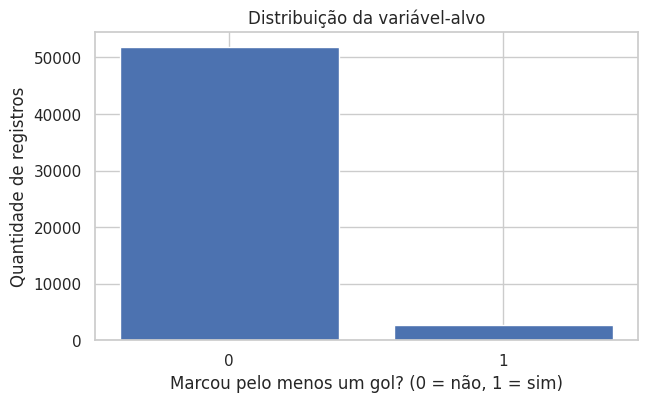

In [13]:
plt.figure(figsize=(7, 4))
counts = df["scored_goal"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribuição da variável-alvo")
plt.xlabel("Marcou pelo menos um gol? (0 = não, 1 = sim)")
plt.ylabel("Quantidade de registros")
plt.show()


A classe positiva é minoritária. Por isso, **acurácia isoladamente pode ser enganosa**: um modelo que sempre previsse “não marcou” teria acurácia alta. Serão avaliadas também precisão, recall, F1 e ROC-AUC.


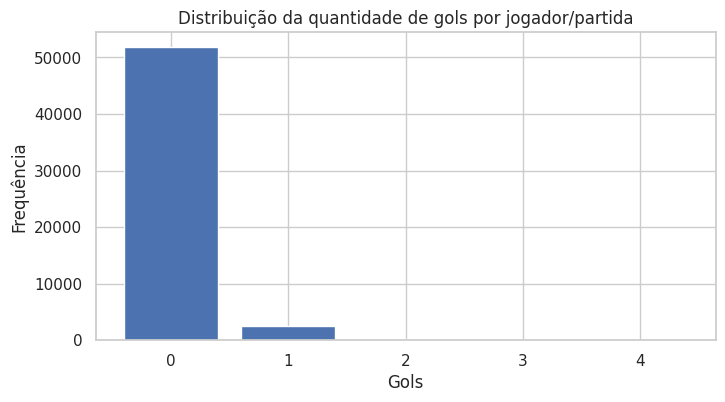

In [14]:
plt.figure(figsize=(8, 4))
goal_counts = df["goals"].value_counts().sort_index()
plt.bar(goal_counts.index.astype(str), goal_counts.values)
plt.title("Distribuição da quantidade de gols por jogador/partida")
plt.xlabel("Gols")
plt.ylabel("Frequência")
plt.show()


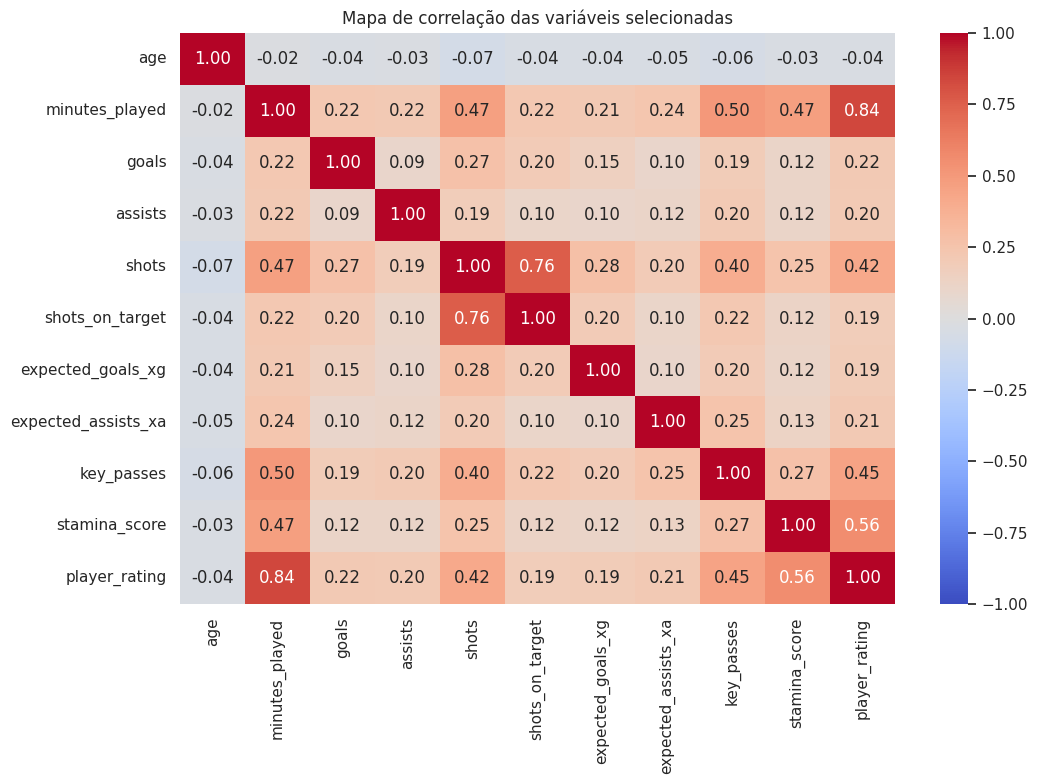

In [15]:
eda_numeric = [
    "age", "minutes_played", "goals", "assists", "shots",
    "shots_on_target", "expected_goals_xg", "expected_assists_xa",
    "key_passes", "stamina_score", "player_rating"
]

corr = df[eda_numeric].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Mapa de correlação das variáveis selecionadas")
plt.tight_layout()
plt.show()


In [19]:
position_summary = (
    df.groupby("position")
      .agg(
          registros=("player_id", "size"),
          gols_medios=("goals", "mean"),
          chance_marcar=("scored_goal", "mean"),
          xg_medio=("expected_goals_xg", "mean"),
          finalizacoes_media=("shots", "mean")
      )
      .sort_values("chance_marcar", ascending=False)
)

# Dicionário de tradução
traducao = {
    "Forward": "Atacante",
    "Midfielder": "Meio-campista",
    "Defender": "Defensor",
    "Goalkeeper": "Goleiro"
}

# Traduz o índice
position_summary.index = position_summary.index.map(traducao)


# Converte a chance para porcentagem
position_summary["chance_marcar"] = (
    position_summary["chance_marcar"] * 100
).round(2)

position_summary.round(3)


,registros,gols_medios,chance_marcar,xg_medio,finalizacoes_media
position,,,,,
Atacante,12600,0.143,12.59,0.047,0.984
Meio-campista,16800,0.052,4.83,0.015,0.471
Defensor,18900,0.019,1.83,0.002,0.217
Goleiro,6300,0.000,0.00,0.000,0.000


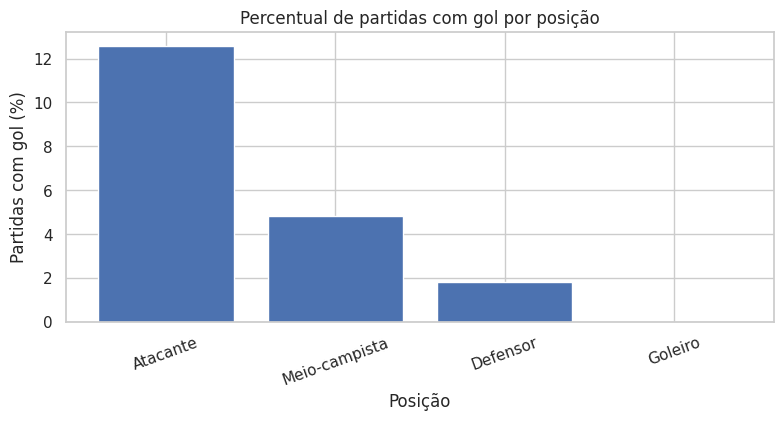

In [24]:
plt.figure(figsize=(8, 4))

position_summary = position_summary.reset_index()
plt.bar(position_summary["position"], position_summary["chance_marcar"])
plt.title("Percentual de partidas com gol por posição")
plt.xlabel("Posição")
plt.ylabel("Partidas com gol (%)")
plt.tight_layout()
plt.xticks(rotation=20)
plt.show()

## 7. Seleção das variáveis preditoras

In [25]:
features = [
    "age",
    "position",
    "preferred_foot",
    "tournament_stage",
    "minutes_played",
    "shots",
    "shots_on_target",
    "expected_goals_xg",
    "expected_assists_xa",
    "key_passes",
    "stamina_score",
    "player_rating"
]

numeric_features = [
    "age", "minutes_played", "shots", "shots_on_target",
    "expected_goals_xg", "expected_assists_xa", "key_passes",
    "stamina_score", "player_rating"
]

categorical_features = [
    "position", "preferred_foot", "tournament_stage"
]

X = df[features].copy()
y_class = df["scored_goal"].copy()
y_reg = df["goals"].copy()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)


Variáveis numéricas: ['age', 'minutes_played', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'stamina_score', 'player_rating']
Variáveis categóricas: ['position', 'preferred_foot', 'tournament_stage']


## 8. Pré-processamento

In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


O pipeline garante que:

- valores numéricos ausentes sejam preenchidos pela mediana;
- variáveis numéricas sejam padronizadas;
- variáveis categóricas sejam convertidas com One-Hot Encoding;
- o mesmo tratamento seja aplicado aos conjuntos de treino e teste.


# Parte A — Classificação: o jogador marcou?

## 9. Separação entre treino e teste

In [27]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_class
)

print("Treino:", X_train_c.shape)
print("Teste:", X_test_c.shape)
print("Proporção positiva no treino:", round(y_train_c.mean(), 4))
print("Proporção positiva no teste:", round(y_test_c.mean(), 4))


Treino: (43680, 12)
Teste: (10920, 12)
Proporção positiva no treino: 0.0502
Proporção positiva no teste: 0.0503


## 10. Treinamento dos classificadores

In [28]:
classification_models = {
    "Regressão Logística": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

fitted_classifiers = {}
classification_results = []

for name, estimator in classification_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train_c, y_train_c)
    pred = pipeline.predict(X_test_c)
    prob = pipeline.predict_proba(X_test_c)[:, 1]

    classification_results.append({
        "modelo": name,
        "acuracia": accuracy_score(y_test_c, pred),
        "precisao": precision_score(y_test_c, pred, zero_division=0),
        "recall": recall_score(y_test_c, pred, zero_division=0),
        "f1": f1_score(y_test_c, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_c, prob)
    })

    fitted_classifiers[name] = pipeline

classification_results = (
    pd.DataFrame(classification_results)
      .set_index("modelo")
      .sort_values("roc_auc", ascending=False)
)

classification_results.round(4)


,acuracia,precisao,recall,f1,roc_auc
modelo,,,,,
Regressão Logística,0.7589,0.1572,0.8707,0.2664,0.8913
Random Forest,0.8527,0.2073,0.6831,0.3181,0.8873
Árvore de Decisão,0.7886,0.1655,0.7923,0.2738,0.8644


## 11. Comparação com um baseline

In [29]:
baseline_pred = np.zeros_like(y_test_c)

baseline = pd.Series({
    "acuracia": accuracy_score(y_test_c, baseline_pred),
    "precisao": precision_score(y_test_c, baseline_pred, zero_division=0),
    "recall": recall_score(y_test_c, baseline_pred, zero_division=0),
    "f1": f1_score(y_test_c, baseline_pred, zero_division=0)
}, name="Baseline: sempre não marcou")

baseline.to_frame().T.round(4)


,acuracia,precisao,recall,f1
Baseline: sempre não marcou,0.9497,0.0,0.0,0.0


O baseline evidencia por que não devemos escolher o modelo apenas pela acurácia. Como a maioria dos jogadores não marca, prever sempre zero pode gerar alta acurácia, mas recall e F1 iguais a zero para a classe de interesse.


## 12. Matrizes de confusão

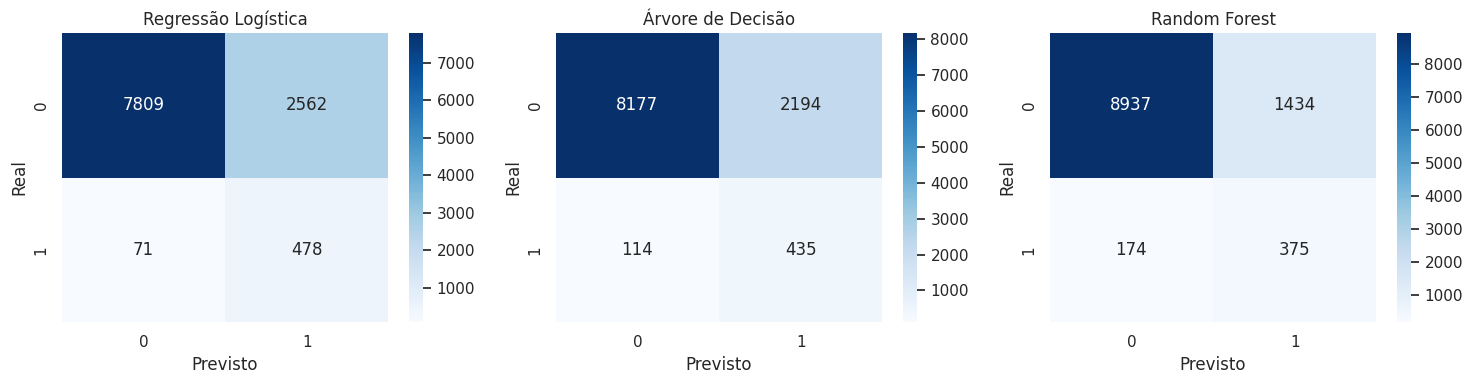

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipeline) in zip(axes, fitted_classifiers.items()):
    pred = pipeline.predict(X_test_c)
    cm = confusion_matrix(y_test_c, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


## 13. Curvas ROC

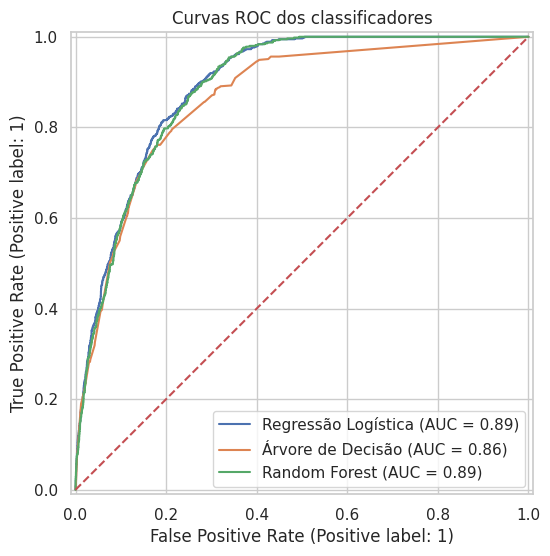

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, pipeline in fitted_classifiers.items():
    RocCurveDisplay.from_estimator(
        pipeline,
        X_test_c,
        y_test_c,
        name=name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Curvas ROC dos classificadores")
plt.show()


## 14. Relatório detalhado do melhor classificador

In [32]:
best_classifier_name = classification_results["roc_auc"].idxmax()
best_classifier = fitted_classifiers[best_classifier_name]
best_class_pred = best_classifier.predict(X_test_c)

print("Melhor modelo por ROC-AUC:", best_classifier_name)
print()
print(classification_report(
    y_test_c,
    best_class_pred,
    target_names=["Não marcou", "Marcou"],
    zero_division=0
))


Melhor modelo por ROC-AUC: Regressão Logística

              precision    recall  f1-score   support

  Não marcou       0.99      0.75      0.86     10371
      Marcou       0.16      0.87      0.27       549

    accuracy                           0.76     10920
   macro avg       0.57      0.81      0.56     10920
weighted avg       0.95      0.76      0.83     10920



## 15. Importância das variáveis no Random Forest

In [33]:
rf_pipeline = fitted_classifiers["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = (
    pd.DataFrame({
        "variavel": feature_names,
        "importancia": rf_model.feature_importances_
    })
    .sort_values("importancia", ascending=False)
    .head(15)
)

feature_importance


,variavel,importancia
8,num__player_rating,0.229738
1,num__minutes_played,0.228522
2,num__shots,0.107366
10,cat__position_Forward,0.075994
4,num__expected_goals_xg,0.052834
7,num__stamina_score,0.049932
6,num__key_passes,0.048762
5,num__expected_assists_xa,0.046245
9,cat__position_Defender,0.039351
0,num__age,0.032011


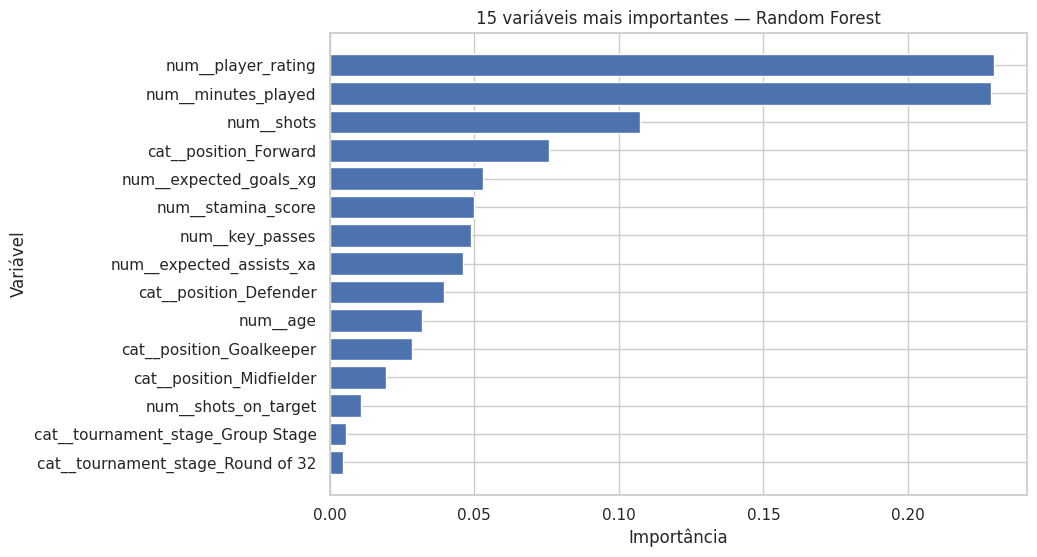

In [34]:
plt.figure(figsize=(9, 6))
plot_data = feature_importance.sort_values("importancia")
plt.barh(plot_data["variavel"], plot_data["importancia"])
plt.title("15 variáveis mais importantes — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()


# Parte B — Regressão: quantidade de gols

## 16. Modelagem de regressão

A variável `goals` é uma contagem não negativa e possui muitos zeros. Além da Regressão Linear, incluiremos a **Regressão de Poisson**, apropriada para dados de contagem, e modelos baseados em árvores.


In [35]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Treino:", X_train_r.shape)
print("Teste:", X_test_r.shape)


Treino: (43680, 12)
Teste: (10920, 12)


In [36]:
regression_models = {
    "Regressão Linear": LinearRegression(),
    "Regressão de Poisson": PoissonRegressor(alpha=0.1, max_iter=1000),
    "Árvore de Decisão": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

fitted_regressors = {}
regression_results = []

for name, estimator in regression_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train_r, y_train_r)
    pred = pipeline.predict(X_test_r)

    # Gols não podem ser negativos; o corte é usado apenas para avaliação/apresentação.
    pred_nonnegative = np.clip(pred, 0, None)

    regression_results.append({
        "modelo": name,
        "MAE": mean_absolute_error(y_test_r, pred_nonnegative),
        "RMSE": mean_squared_error(y_test_r, pred_nonnegative) ** 0.5,
        "R2": r2_score(y_test_r, pred_nonnegative)
    })

    fitted_regressors[name] = pipeline

regression_results = (
    pd.DataFrame(regression_results)
      .set_index("modelo")
      .sort_values("MAE")
)

regression_results.round(4)


,MAE,RMSE,R2
modelo,,,
Árvore de Decisão,0.0861,0.2360,0.1492
Random Forest,0.0876,0.2351,0.1560
Regressão de Poisson,0.0979,0.2456,0.0790
Regressão Linear,0.1012,0.2412,0.1117


## 17. Baseline da regressão

In [37]:
# Baseline conservador: prever sempre a média de gols do treino.
baseline_reg_pred = np.repeat(y_train_r.mean(), len(y_test_r))

baseline_reg = pd.Series({
    "MAE": mean_absolute_error(y_test_r, baseline_reg_pred),
    "RMSE": mean_squared_error(y_test_r, baseline_reg_pred) ** 0.5,
    "R2": r2_score(y_test_r, baseline_reg_pred)
}, name="Baseline: média do treino")

baseline_reg.to_frame().T.round(4)


,MAE,RMSE,R2
Baseline: média do treino,0.1061,0.2559,-0.0


## 18. Valores reais versus previstos

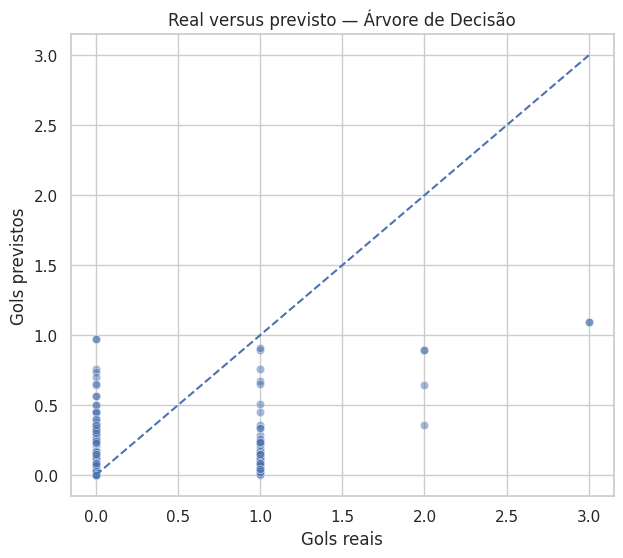

In [38]:
best_regressor_name = regression_results["MAE"].idxmin()
best_regressor = fitted_regressors[best_regressor_name]

best_reg_pred = np.clip(best_regressor.predict(X_test_r), 0, None)

comparison = pd.DataFrame({
    "real": y_test_r.values,
    "previsto": best_reg_pred
}).sample(1000, random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=comparison, x="real", y="previsto", alpha=0.5)
max_value = max(comparison["real"].max(), comparison["previsto"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")
plt.title(f"Real versus previsto — {best_regressor_name}")
plt.xlabel("Gols reais")
plt.ylabel("Gols previstos")
plt.show()


## 19. Exemplo de previsão

In [39]:
example_player = pd.DataFrame([{
    "age": 25,
    "position": "Forward",
    "preferred_foot": "Right",
    "tournament_stage": "Group Stage",
    "minutes_played": 90,
    "shots": 5,
    "shots_on_target": 3,
    "expected_goals_xg": 0.80,
    "expected_assists_xa": 0.15,
    "key_passes": 2,
    "stamina_score": 85,
    "player_rating": 7.8
}])

prob_goal = best_classifier.predict_proba(example_player)[0, 1]
predicted_goals = max(0, best_regressor.predict(example_player)[0])

print(f"Probabilidade estimada de marcar: {prob_goal:.1%}")
print(f"Quantidade estimada de gols: {predicted_goals:.2f}")


Probabilidade estimada de marcar: 97.0%
Quantidade estimada de gols: 0.76


## 20. Conclusões

In [40]:
best_c = classification_results.iloc[0]
best_r = regression_results.iloc[0]

print("CLASSIFICAÇÃO")
print(
    f"O melhor classificador por ROC-AUC foi {classification_results.index[0]}, "
    f"com ROC-AUC de {best_c['roc_auc']:.3f}, recall de {best_c['recall']:.3f} "
    f"e F1 de {best_c['f1']:.3f}."
)

print("\nREGRESSÃO")
print(
    f"O menor MAE foi obtido por {regression_results.index[0]}, "
    f"com MAE de {best_r['MAE']:.3f} gol(s), RMSE de {best_r['RMSE']:.3f} "
    f"e R² de {best_r['R2']:.3f}."
)

print("\nINTERPRETAÇÃO")
print(
    "A forte concentração de zeros torna a previsão difícil e exige métricas "
    "adequadas. Para a classificação, recall, F1 e ROC-AUC são mais informativos "
    "que a acurácia isolada. Para a regressão, MAE e RMSE devem ser comparados ao baseline."
)


CLASSIFICAÇÃO
O melhor classificador por ROC-AUC foi Regressão Logística, com ROC-AUC de 0.891, recall de 0.871 e F1 de 0.266.

REGRESSÃO
O menor MAE foi obtido por Árvore de Decisão, com MAE de 0.086 gol(s), RMSE de 0.236 e R² de 0.149.

INTERPRETAÇÃO
A forte concentração de zeros torna a previsão difícil e exige métricas adequadas. Para a classificação, recall, F1 e ROC-AUC são mais informativos que a acurácia isolada. Para a regressão, MAE e RMSE devem ser comparados ao baseline.
